<a href="https://colab.research.google.com/github/Jishnu24638/Final-Project/blob/main/my_code_crop_prediction_untill_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing pandas and numpy
import pandas as pd
import numpy as np
# loading dataset
df = pd.read_csv("India Agriculture Crop Production.csv")
df.shape

(345407, 10)

In [ ]:
# previewing data
df.head()

# column names
df.columns

# data types
df.dtypes

,0
State,object
District,object
Crop,object
Year,object
Season,object
Area,float64
Area Units,object
Production,float64
Production Units,object
Yield,float64


In [ ]:
# making column names consistent
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

# cleaning text columns (remove extra spaces)
df["state"] = df["state"].astype(str).str.strip()
df["district"] = df["district"].astype(str).str.strip()
df["crop"] = df["crop"].astype(str).str.strip()
df["season"] = df["season"].astype(str).str.strip()
df["area_units"] = df["area_units"].astype(str).str.strip()
df["production_units"] = df["production_units"].astype(str).str.strip()


In [ ]:
# converting year like '2012-13' to 2012
df["year"] = df["year"].astype(str).str.split("-").str[0]
df["year"] = pd.to_numeric(df["year"], errors="coerce")

In [ ]:
# check missing values
df.isnull().sum()

# droping rows with missing key values
df = df.dropna(subset=["state", "district", "crop", "season", "year", "area", "production", "yield"])

df.shape

(340414, 10)

In [ ]:
# removing yield outliers using IQR
q1 = df["yield"].quantile(0.25)
q3 = df["yield"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df = df[(df["yield"] >= lower) & (df["yield"] <= upper)]

# removing duplicates
df = df.drop_duplicates().reset_index(drop=True)

df.shape

(289086, 10)

In [ ]:
# final dataset check for EDA
df.info()
df.head()

# saving cleaned data
df.to_csv("cleaned_crop_data.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289086 entries, 0 to 289085
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   state             289086 non-null  object 
 1   district          289086 non-null  object 
 2   crop              289086 non-null  object 
 3   year              289086 non-null  int64  
 4   season            289086 non-null  object 
 5   area              289086 non-null  float64
 6   area_units        289086 non-null  object 
 7   production        289086 non-null  float64
 8   production_units  289086 non-null  object 
 9   yield             289086 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 22.1+ MB


In [ ]:
# basic stats for numeric columns
df.describe()

# unique counts for key columns
df[["state", "district", "crop", "season"]].nunique()

,0
state,36
district,727
crop,55
season,6


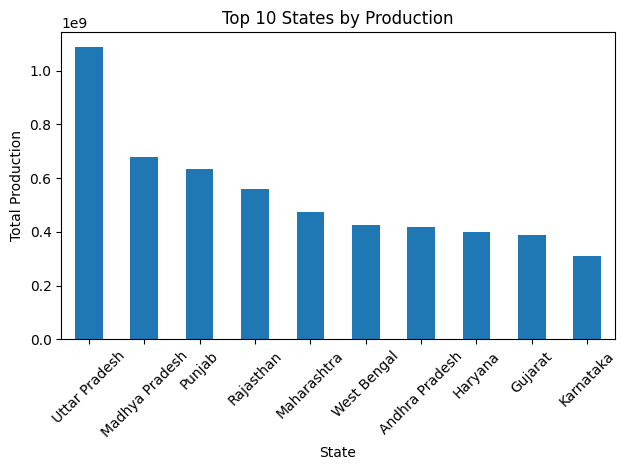

In [ ]:
import matplotlib.pyplot as plt

# top states by total production
state_prod = df.groupby("state")["production"].sum().sort_values(ascending=False).head(10)

state_prod.plot(kind="bar")
plt.title("Top 10 States by Production")
plt.xlabel("State")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

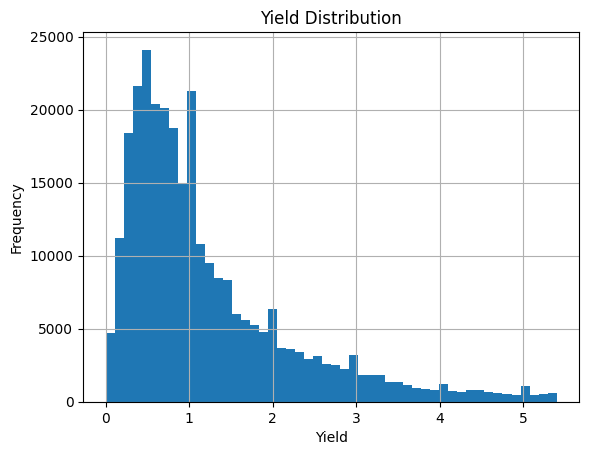

In [ ]:
# distribution of yield
df["yield"].hist(bins=50)

plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

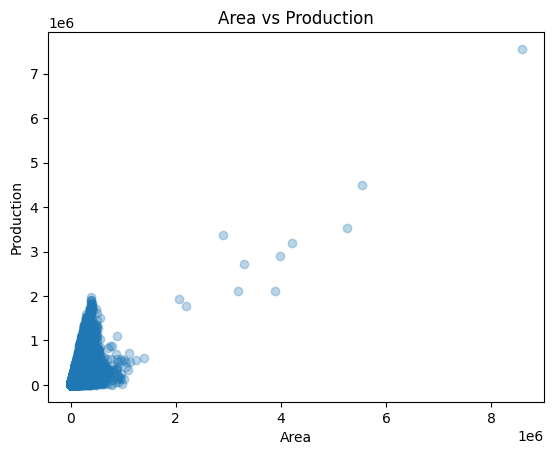

In [ ]:
# relationship between area and production
plt.scatter(df["area"], df["production"], alpha=0.3)

plt.title("Area vs Production")
plt.xlabel("Area")
plt.ylabel("Production")
plt.show()

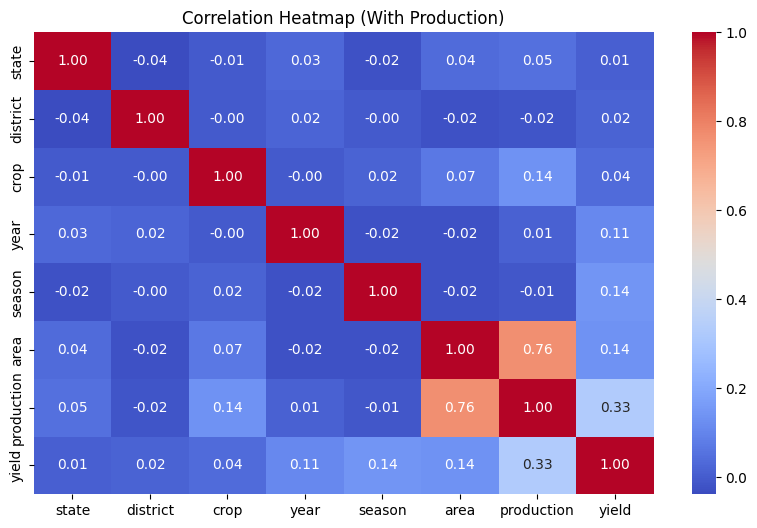

In [ ]:
# copy dataset
df_corr = df.copy()

# drop only useless columns
df_corr = df_corr.drop(columns=["area_units", "production_units"])

#encode categorical columns
from sklearn.preprocessing import LabelEncoder

cat_cols = ["state", "district", "season","crop"]

for col in cat_cols:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col])

# correlation matrix
corr = df_corr.corr()

# plot heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap (With Production)")
plt.show()

In [ ]:
# select input features and target variable
# removing yield (target) and unnecessary unit columns

X = df.drop(columns=["yield", "area_units", "production_units",'production'], errors="ignore")
y = df["yield"]

In [ ]:
from sklearn.model_selection import train_test_split

# spliting data into training and testing sets into 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#importing ordinal coder to convert categorical values into binary for training model
from sklearn.preprocessing import OrdinalEncoder

cat_cols = ["state", "district", "crop", "season"]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [ ]:
#Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

rf_pred = rf.predict(X_test)

# metrics of random forest
r2_rf = r2_score(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_rf = mean_absolute_error(y_test, rf_pred)

# printing results of random forest
print("Random Forest Performance")
print("-------------------------")
print("R2 Score :", round(r2_rf, 4))
print("RMSE     :", round(rmse_rf, 4))
print("MAE      :", round(mae_rf, 4))

Random Forest Performance
-------------------------
R2 Score : 0.8634
RMSE     : 0.3821
MAE      : 0.2147


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Creating the XGBoost model
xgb = XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1)

# Training the model on the training data
xgb.fit(X_train, y_train)

# Making predictions on the test data
xgb_pred = xgb.predict(X_test)

# Calculating evaluation metrics
r2_xgb = r2_score(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae_xgb = mean_absolute_error(y_test, xgb_pred)

# Printing the model results
print("XGBoost Performance")
print("-------------------")
print("R2 Score :", round(r2_xgb, 4))
print("RMSE     :", round(rmse_xgb, 4))
print("MAE      :", round(mae_xgb, 4))

XGBoost Performance
-------------------
R2 Score : 0.7949
RMSE     : 0.4682
MAE      : 0.3038


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# Scaling the data for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating the ANN model
ann = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)

# Training the model on the training data
ann.fit(X_train_scaled, y_train)

# Making predictions on the test data
ann_pred = ann.predict(X_test_scaled)

# Calculating evaluation metrics
r2_ann = r2_score(y_test, ann_pred)
rmse_ann = np.sqrt(mean_squared_error(y_test, ann_pred))
mae_ann = mean_absolute_error(y_test, ann_pred)

# Printing the model results
print("ANN Performance")
print("----------------")
print("R2 Score :", round(r2_ann, 4))
print("RMSE     :", round(rmse_ann, 4))
print("MAE      :", round(mae_ann, 4))

ANN Performance
----------------
R2 Score : 0.5964
RMSE     : 0.6568
MAE      : 0.4451


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


    Feature  Importance
2      crop    0.429179
0     state    0.206255
5      area    0.126530
3      year    0.094054
1  district    0.072190
4    season    0.071792


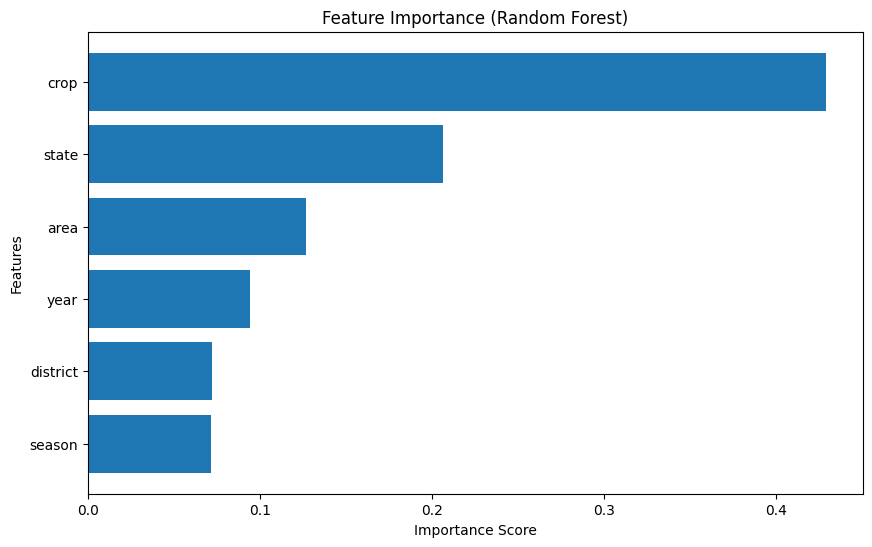

In [ ]:
#Feature importace of random forest regressor
import pandas as pd
import matplotlib.pyplot as plt
importances = rf.feature_importances_

# creating dataframe for better visualization
feat_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# sorting features by importance
feat_importance = feat_importance.sort_values(by="Importance", ascending=False)

print(feat_importance)

# ploting for importance features
plt.figure(figsize=(10, 6))
plt.barh(feat_importance["Feature"], feat_importance["Importance"])
plt.gca().invert_yaxis()

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()